# Plotting Analytical Solutions (and Comparing Them)

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
base_folder = "F:\\Projects\\EMGeoInversion\\Tests_Thesis\\semi-analytic_100MHz"

## Evert's Half-Space Solution

In [2]:
analytical_file = os.path.join(base_folder, "Exx_single_freq_4_100MHz.csv")
analytical_lines = np.loadtxt(analytical_file, delimiter=',', skiprows=1)

r = analytical_lines[:, 0]

# Endfire
abs_endfire = analytical_lines[:, 1]
phase_endfire = analytical_lines[:, 2]
real_endfire = analytical_lines[:, 3]
imag_endfire = analytical_lines[:, 4]

# Broadside
abs_broadside = analytical_lines[:, 5]
phase_broadside = analytical_lines[:, 6]
real_broadside = analytical_lines[:, 7]
imag_broadside = analytical_lines[:, 8]

# Oblique
abs_45deg = analytical_lines[:, 9]
phase_45deg = analytical_lines[:, 10]
real_45deg = analytical_lines[:, 11]
imag_45deg = analytical_lines[:, 12]

dataset_evert_4 = [
    (abs_endfire, phase_endfire, real_endfire, imag_endfire, 'Endfire', r, 'Evert'),
    (abs_broadside, phase_broadside, real_broadside, imag_broadside, 'Broadside', r, 'Evert'),
    (abs_45deg, phase_45deg, real_45deg, imag_45deg, 'Oblique', r, 'Evert')
]
quantities = [
    ('Amplitude (Ex)', 'Amplitude (V/m)'),
    ('Phase (Ex)', 'Phase (rad)'),
    ('Real (Ex)', 'Real (V/m)'),
    ('Imaginary (Ex)', 'Imaginary (V/m)')
]

## empymod's Half-Space Solution Using the 2001 Point Filter

In [3]:
analytical_file = os.path.join(base_folder, "GPR-2001-4-dlf.csv")
analytical_lines = np.loadtxt(analytical_file, delimiter=',', skiprows=1)

r = analytical_lines[:, 0]

# Endfire
abs_endfire = analytical_lines[:, 1]
phase_endfire = analytical_lines[:, 2]
real_endfire = analytical_lines[:, 3]
imag_endfire = analytical_lines[:, 4]

# Broadside
abs_broadside = analytical_lines[:, 5]
phase_broadside = analytical_lines[:, 6]
real_broadside = analytical_lines[:, 7]
imag_broadside = analytical_lines[:, 8]

# Oblique
abs_45deg = analytical_lines[:, 9]
phase_45deg = analytical_lines[:, 10]
real_45deg = analytical_lines[:, 11]
imag_45deg = analytical_lines[:, 12]

dataset_empymod_4_dlf = [
    (abs_endfire, phase_endfire, real_endfire, imag_endfire, 'Endfire', r, 'empymod - 2001 DLF'),
    (abs_broadside, phase_broadside, real_broadside, imag_broadside, 'Broadside', r, 'empymod - 2001 DLF'),
    (abs_45deg, phase_45deg, real_45deg, imag_45deg, 'Oblique', r, 'empymod - 2001 DLF')
]
quantities = [
    ('Amplitude (Ex)', 'Amplitude (V/m)'),
    ('Phase (Ex)', 'Phase (rad)'),
    ('Real (Ex)', 'Real (V/m)'),
    ('Imaginary (Ex)', 'Imaginary (V/m)')
]

In [4]:
analytical_file = os.path.join(base_folder, "GPR-2001-4-qwe.csv")
analytical_lines = np.loadtxt(analytical_file, delimiter=',', skiprows=1)

r = analytical_lines[:, 0]

# Endfire
abs_endfire = analytical_lines[:, 1]
phase_endfire = analytical_lines[:, 2]
real_endfire = analytical_lines[:, 3]
imag_endfire = analytical_lines[:, 4]

# Broadside
abs_broadside = analytical_lines[:, 5]
phase_broadside = analytical_lines[:, 6]
real_broadside = analytical_lines[:, 7]
imag_broadside = analytical_lines[:, 8]

# Oblique
abs_45deg = analytical_lines[:, 9]
phase_45deg = analytical_lines[:, 10]
real_45deg = analytical_lines[:, 11]
imag_45deg = analytical_lines[:, 12]

dataset_empymod_4_qwe = [
    (abs_endfire, phase_endfire, real_endfire, imag_endfire, 'Endfire', r, 'empymod - QWE'),
    (abs_broadside, phase_broadside, real_broadside, imag_broadside, 'Broadside', r, 'empymod - QWE'),
    (abs_45deg, phase_45deg, real_45deg, imag_45deg, 'Oblique', r, 'empymod - QWE')
]
quantities = [
    ('Amplitude (Ex)', 'Amplitude (V/m)'),
    ('Phase (Ex)', 'Phase (rad)'),
    ('Real (Ex)', 'Real (V/m)'),
    ('Imaginary (Ex)', 'Imaginary (V/m)')
]

## Comparing Half-Space Solutions

### Direct Plot

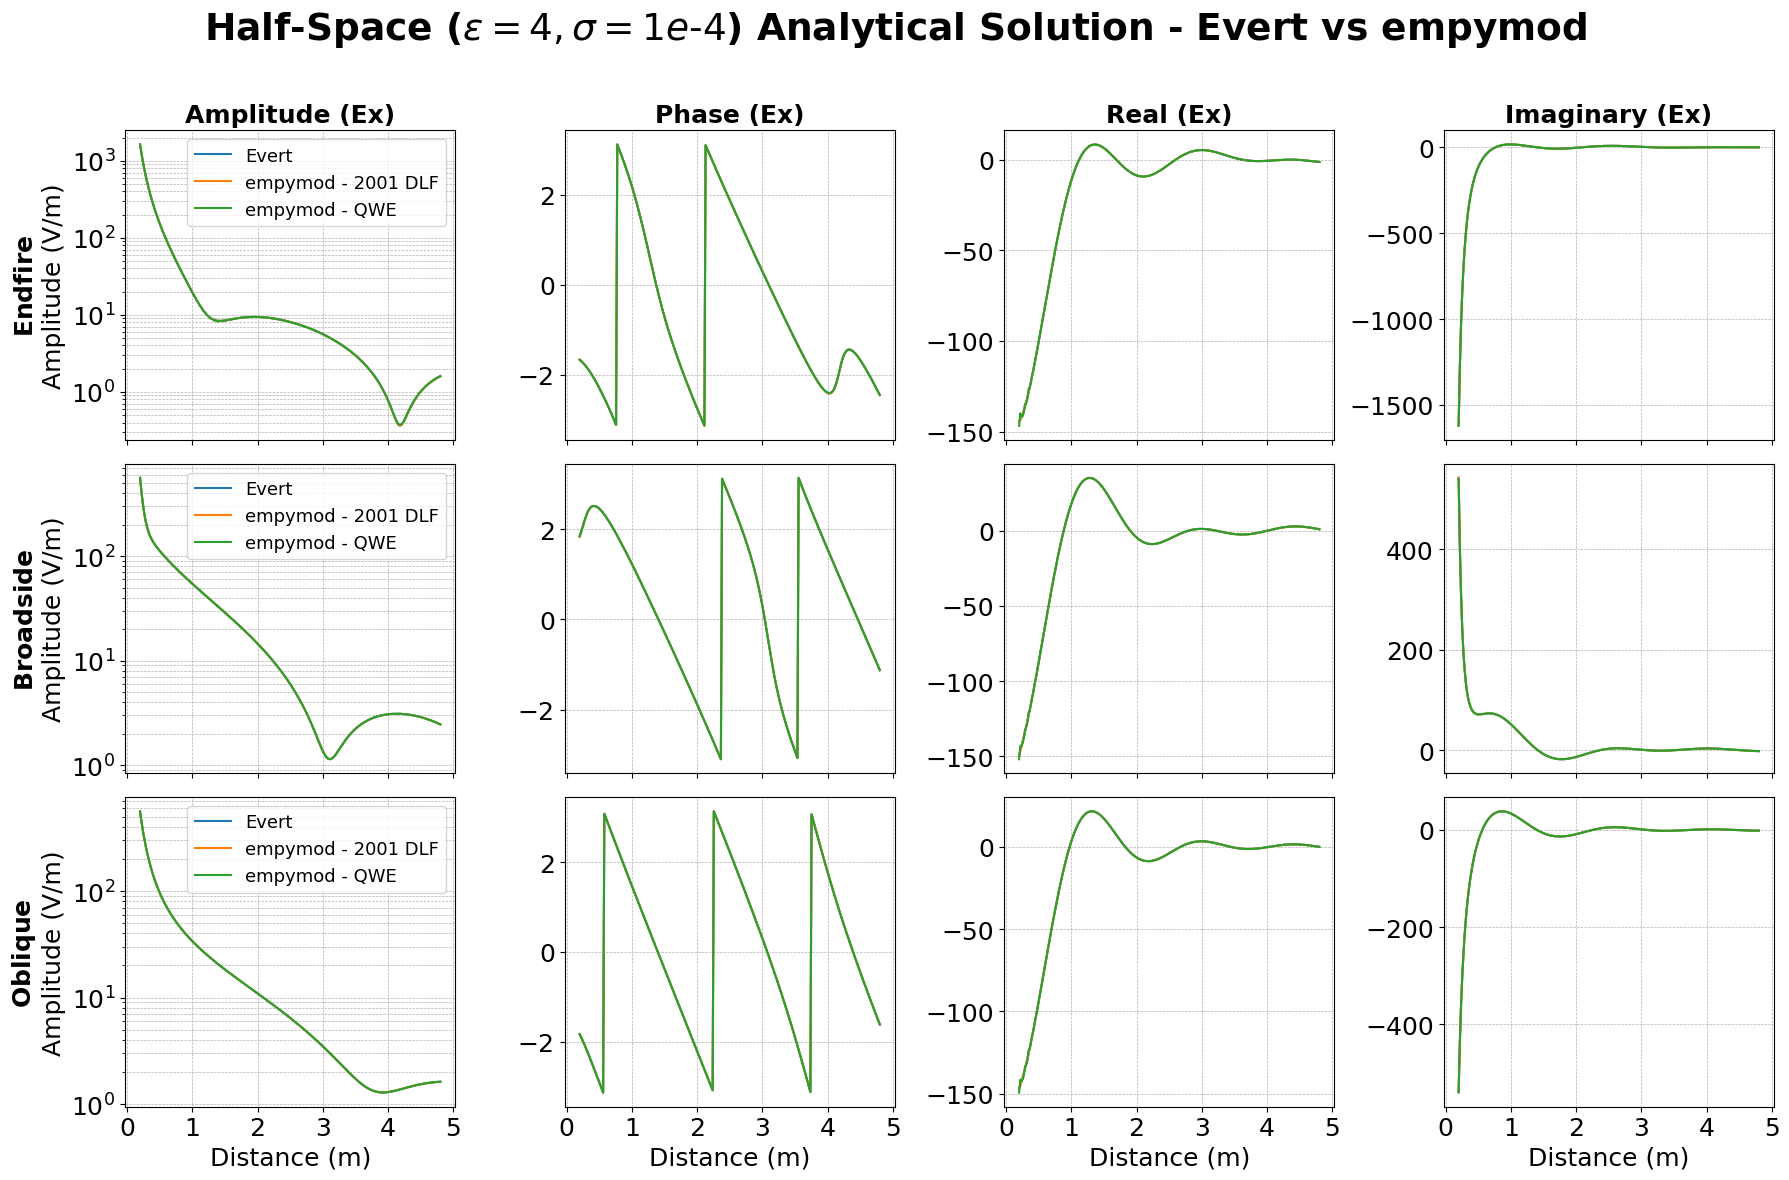

In [5]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12), sharex=True)

# Use datasets from both Evert and empymod
datasets_4 = dataset_evert_4 + dataset_empymod_4_dlf + dataset_empymod_4_qwe

font_suptitle = 27
font_label = 18
font_tick = 18
font_legend = 13

for i, (amp, phase, real, imag, label, axis, source) in enumerate(datasets_4):
    row = i % 3
    for col, (title, ylabel) in enumerate(quantities):
        ax = axes[row, col]
        plot_label = source
        if col == 0:
            ax.semilogy(axis, [amp, phase, real, imag][col], label=plot_label)
            ax.grid(True, which='both', linestyle='--', linewidth=0.5)
            ax.legend(fontsize=font_legend, loc='upper right')
        else:
            ax.plot(axis, [amp, phase, real, imag][col], label=plot_label)
            ax.grid(True, linestyle='--', linewidth=0.5)
        if row == 0:
            ax.set_title(title, fontsize=font_label, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f"$\\bf{{{label}}}$\n{ylabel}", fontsize=font_label)
        if row == 2:
            ax.set_xlabel('Distance (m)', fontsize=font_label)
        xticks = np.arange(np.floor(axis.min() * 2) / 2, np.ceil(axis.max() * 2) / 2 + 0.01, 1)
        ax.set_xticks(xticks)
        ax.tick_params(axis='both', which='major', labelsize=font_tick)
    
fig.suptitle(r"Half-Space ($\varepsilon=4, \sigma=1e\text{-}4$) Analytical Solution - Evert vs empymod", fontsize=font_suptitle, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(base_folder, "halfspace_4_solution_comparison.png"), dpi=300)
plt.show()

### Error Plot

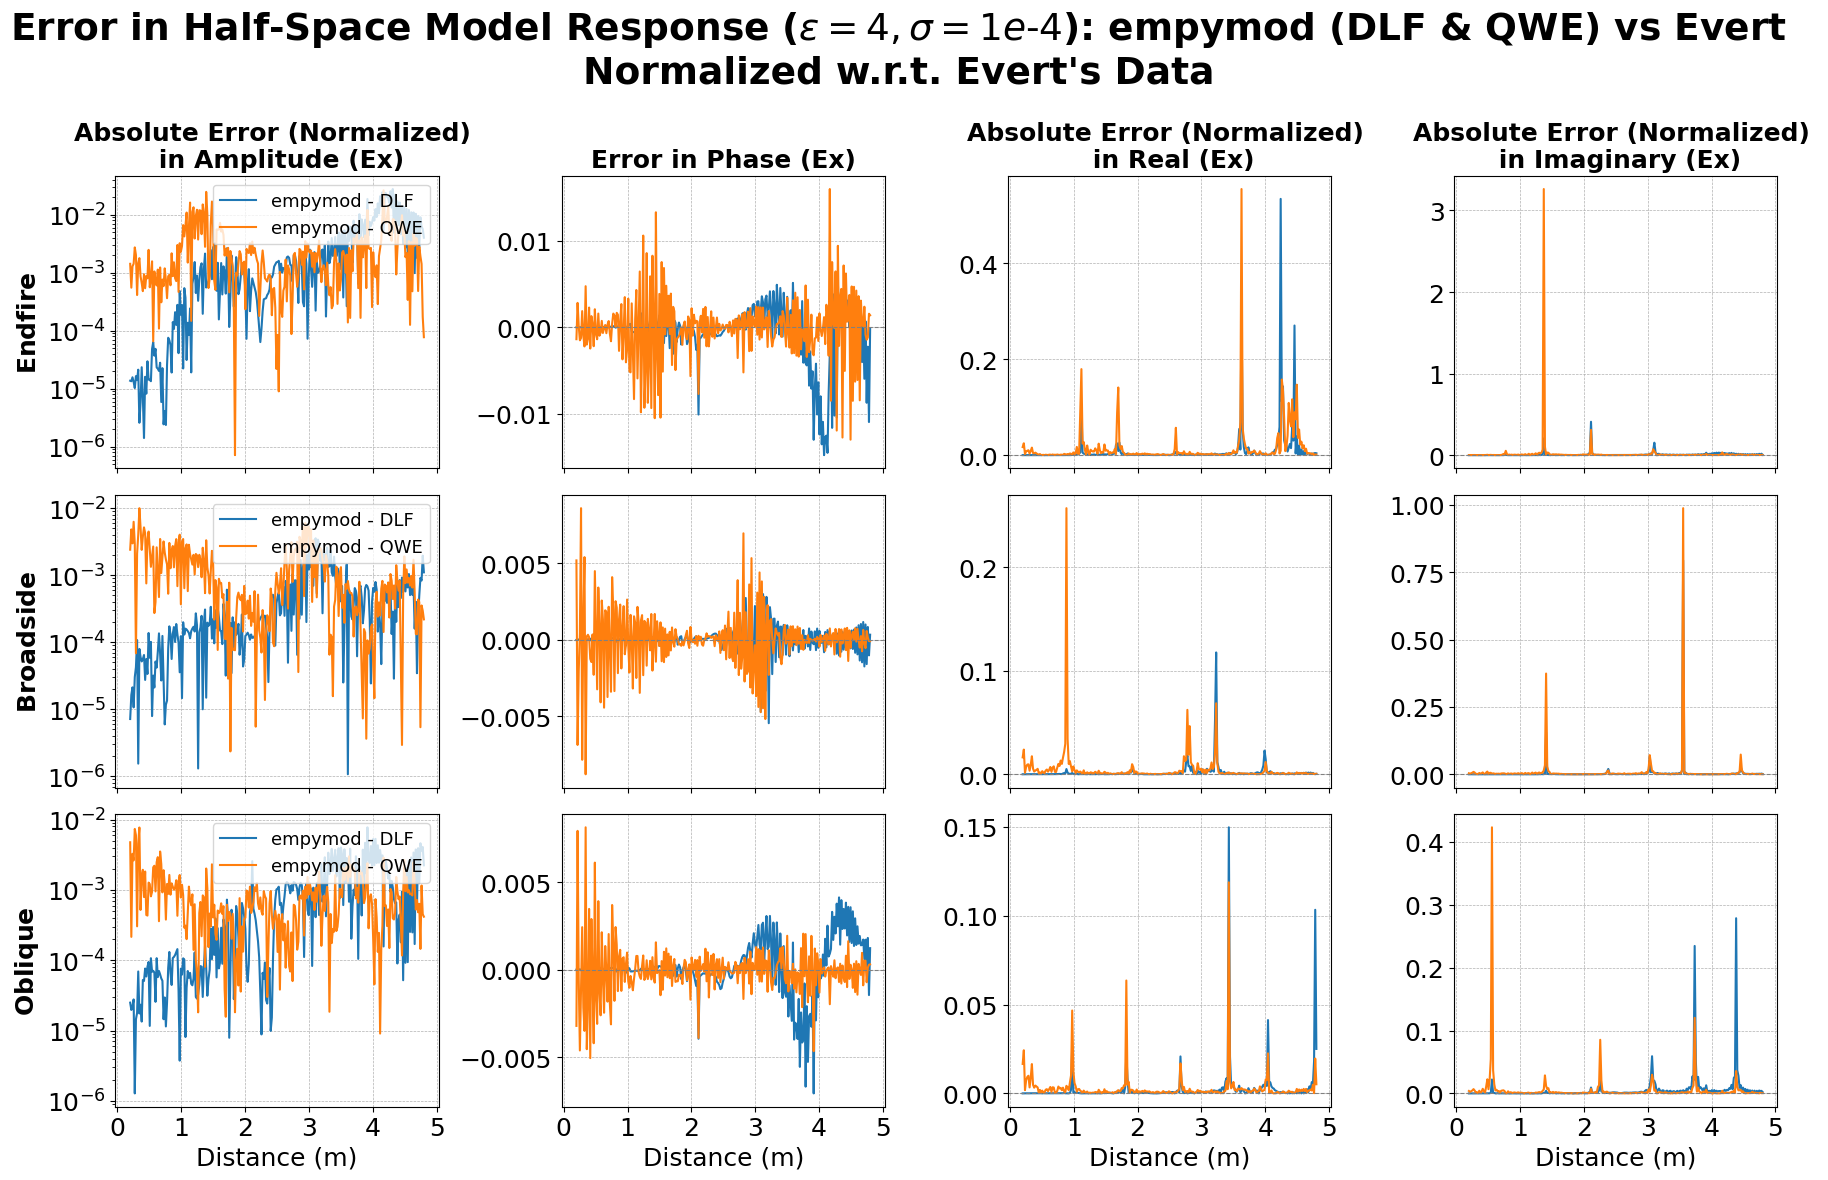

In [6]:
# Calculate normalised differences between Evert and both empymod datasets for each orientation and quantity
diff_datasets_4 = []
for i in range(3):  # Endfire, Broadside, Oblique
    evert = dataset_evert_4[i]
    empy_dlf = dataset_empymod_4_dlf[i]
    empy_qwe = dataset_empymod_4_qwe[i]
    amp_diff_dlf = np.abs(empy_dlf[0] - evert[0]) / np.abs(evert[0])
    phase_diff_dlf = empy_dlf[1] - evert[1]
    real_diff_dlf = np.abs(empy_dlf[2] - evert[2]) / np.abs(evert[2])
    imag_diff_dlf = np.abs(empy_dlf[3] - evert[3]) / np.abs(evert[3])
    amp_diff_qwe = np.abs(empy_qwe[0] - evert[0]) / np.abs(evert[0])
    phase_diff_qwe = empy_qwe[1] - evert[1]
    real_diff_qwe = np.abs(empy_qwe[2] - evert[2]) / np.abs(evert[2])
    imag_diff_qwe = np.abs(empy_qwe[3] - evert[3]) / np.abs(evert[3])
    diff = (
        (amp_diff_dlf, phase_diff_dlf, real_diff_dlf, imag_diff_dlf),
        (amp_diff_qwe, phase_diff_qwe, real_diff_qwe, imag_diff_qwe),
        evert[4],  # Label
        evert[5]   # r
    )
    diff_datasets_4.append(diff)

fig, axes = plt.subplots(3, 4, figsize=(18, 12), sharex=True)
for row, (diff_dlf, diff_qwe, label, axis) in enumerate(diff_datasets_4):
    for col, (title, ylabel) in enumerate(quantities):
        ax = axes[row, col]
        if col == 0:
            # Plot amplitude error with log scale y
            ax.semilogy(axis, diff_dlf[col], label='empymod - DLF')
            ax.semilogy(axis, diff_qwe[col], label='empymod - QWE')
        else:
            ax.plot(axis, diff_dlf[col], label='empymod - DLF')
            ax.plot(axis, diff_qwe[col], label='empymod - QWE')
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
        ax.grid(True, linestyle='--', linewidth=0.5)
        if row == 0:
            if title != 'Phase (Ex)':
                ax.set_title(f"Absolute Error (Normalized) \n in {title}", fontsize=font_label, fontweight='bold')
            else:
                ax.set_title(f"Error in {title}", fontsize=font_label, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f"$\\bf{{{label}}}$", fontsize=font_label)
        if row == 2:
            ax.set_xlabel('Distance (m)', fontsize=font_label)
        xticks = np.arange(np.floor(axis.min() * 2) / 2, np.ceil(axis.max() * 2) / 2 + 0.01, 1)
        ax.set_xticks(xticks)
        ax.tick_params(axis='both', which='major', labelsize=font_tick)
        if col == 0:
            ax.legend(fontsize=font_legend, loc='upper right')

fig.suptitle(r"Error in Half-Space Model Response ($\varepsilon=4, \sigma=1e\text{-}4$): empymod (DLF & QWE) vs Evert" "\n" r"Normalized w.r.t. Evert's Data", fontsize=font_suptitle, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(os.path.join(base_folder, "halfspace_4_solution_normalized_error.png"), dpi=300)
plt.show()


## Evert's Two Layered Model Solution

In [7]:
analytical_file = os.path.join(base_folder, "Exx_single_freq_4_9_100MHz.csv")
analytical_lines = np.loadtxt(analytical_file, delimiter=',', skiprows=1)

r = analytical_lines[:, 0]

# Endfire
abs_endfire = analytical_lines[:, 1]
phase_endfire = analytical_lines[:, 2]
real_endfire = analytical_lines[:, 3]
imag_endfire = analytical_lines[:, 4]

# Broadside
abs_broadside = analytical_lines[:, 5]
phase_broadside = analytical_lines[:, 6]
real_broadside = analytical_lines[:, 7]
imag_broadside = analytical_lines[:, 8]

# Oblique
abs_45deg = analytical_lines[:, 9]
phase_45deg = analytical_lines[:, 10]
real_45deg = analytical_lines[:, 11]
imag_45deg = analytical_lines[:, 12]

dataset_evert_4_9 = [
    (abs_endfire, phase_endfire, real_endfire, imag_endfire, 'Endfire', r, 'Evert'),
    (abs_broadside, phase_broadside, real_broadside, imag_broadside, 'Broadside', r, 'Evert'),
    (abs_45deg, phase_45deg, real_45deg, imag_45deg, 'Oblique', r, 'Evert')
]

## empymod's Two Layered Model Solution Using the 2001 Point Filter

In [8]:
analytical_file = os.path.join(base_folder, "GPR-2001-49-dlf.csv")
analytical_lines = np.loadtxt(analytical_file, delimiter=',', skiprows=1)

r = analytical_lines[:, 0]

# Endfire
abs_endfire = analytical_lines[:, 1]
phase_endfire = analytical_lines[:, 2]
real_endfire = analytical_lines[:, 3]
imag_endfire = analytical_lines[:, 4]

# Broadside
abs_broadside = analytical_lines[:, 5]
phase_broadside = analytical_lines[:, 6]
real_broadside = analytical_lines[:, 7]
imag_broadside = analytical_lines[:, 8]

# Oblique
abs_45deg = analytical_lines[:, 9]
phase_45deg = analytical_lines[:, 10]
real_45deg = analytical_lines[:, 11]
imag_45deg = analytical_lines[:, 12]

dataset_empymod_4_9_dlf = [
    (abs_endfire, phase_endfire, real_endfire, imag_endfire, 'Endfire', r, 'empymod - 2001 DLF'),
    (abs_broadside, phase_broadside, real_broadside, imag_broadside, 'Broadside', r, 'empymod - 2001 DLF'),
    (abs_45deg, phase_45deg, real_45deg, imag_45deg, 'Oblique', r, 'empymod - 2001 DLF')
]

In [9]:
analytical_file = os.path.join(base_folder, "GPR-2001-49-qwe.csv")
analytical_lines = np.loadtxt(analytical_file, delimiter=',', skiprows=1)

r = analytical_lines[:, 0]

# Endfire
abs_endfire = analytical_lines[:, 1]
phase_endfire = analytical_lines[:, 2]
real_endfire = analytical_lines[:, 3]
imag_endfire = analytical_lines[:, 4]

# Broadside
abs_broadside = analytical_lines[:, 5]
phase_broadside = analytical_lines[:, 6]
real_broadside = analytical_lines[:, 7]
imag_broadside = analytical_lines[:, 8]

# Oblique
abs_45deg = analytical_lines[:, 9]
phase_45deg = analytical_lines[:, 10]
real_45deg = analytical_lines[:, 11]
imag_45deg = analytical_lines[:, 12]

dataset_empymod_4_9_qwe = [
    (abs_endfire, phase_endfire, real_endfire, imag_endfire, 'Endfire', r, 'empymod - QWE'),
    (abs_broadside, phase_broadside, real_broadside, imag_broadside, 'Broadside', r, 'empymod - QWE'),
    (abs_45deg, phase_45deg, real_45deg, imag_45deg, 'Oblique', r, 'empymod - QWE')
]

## Comparing Two-Layered Model Solutions

### Direct Plot

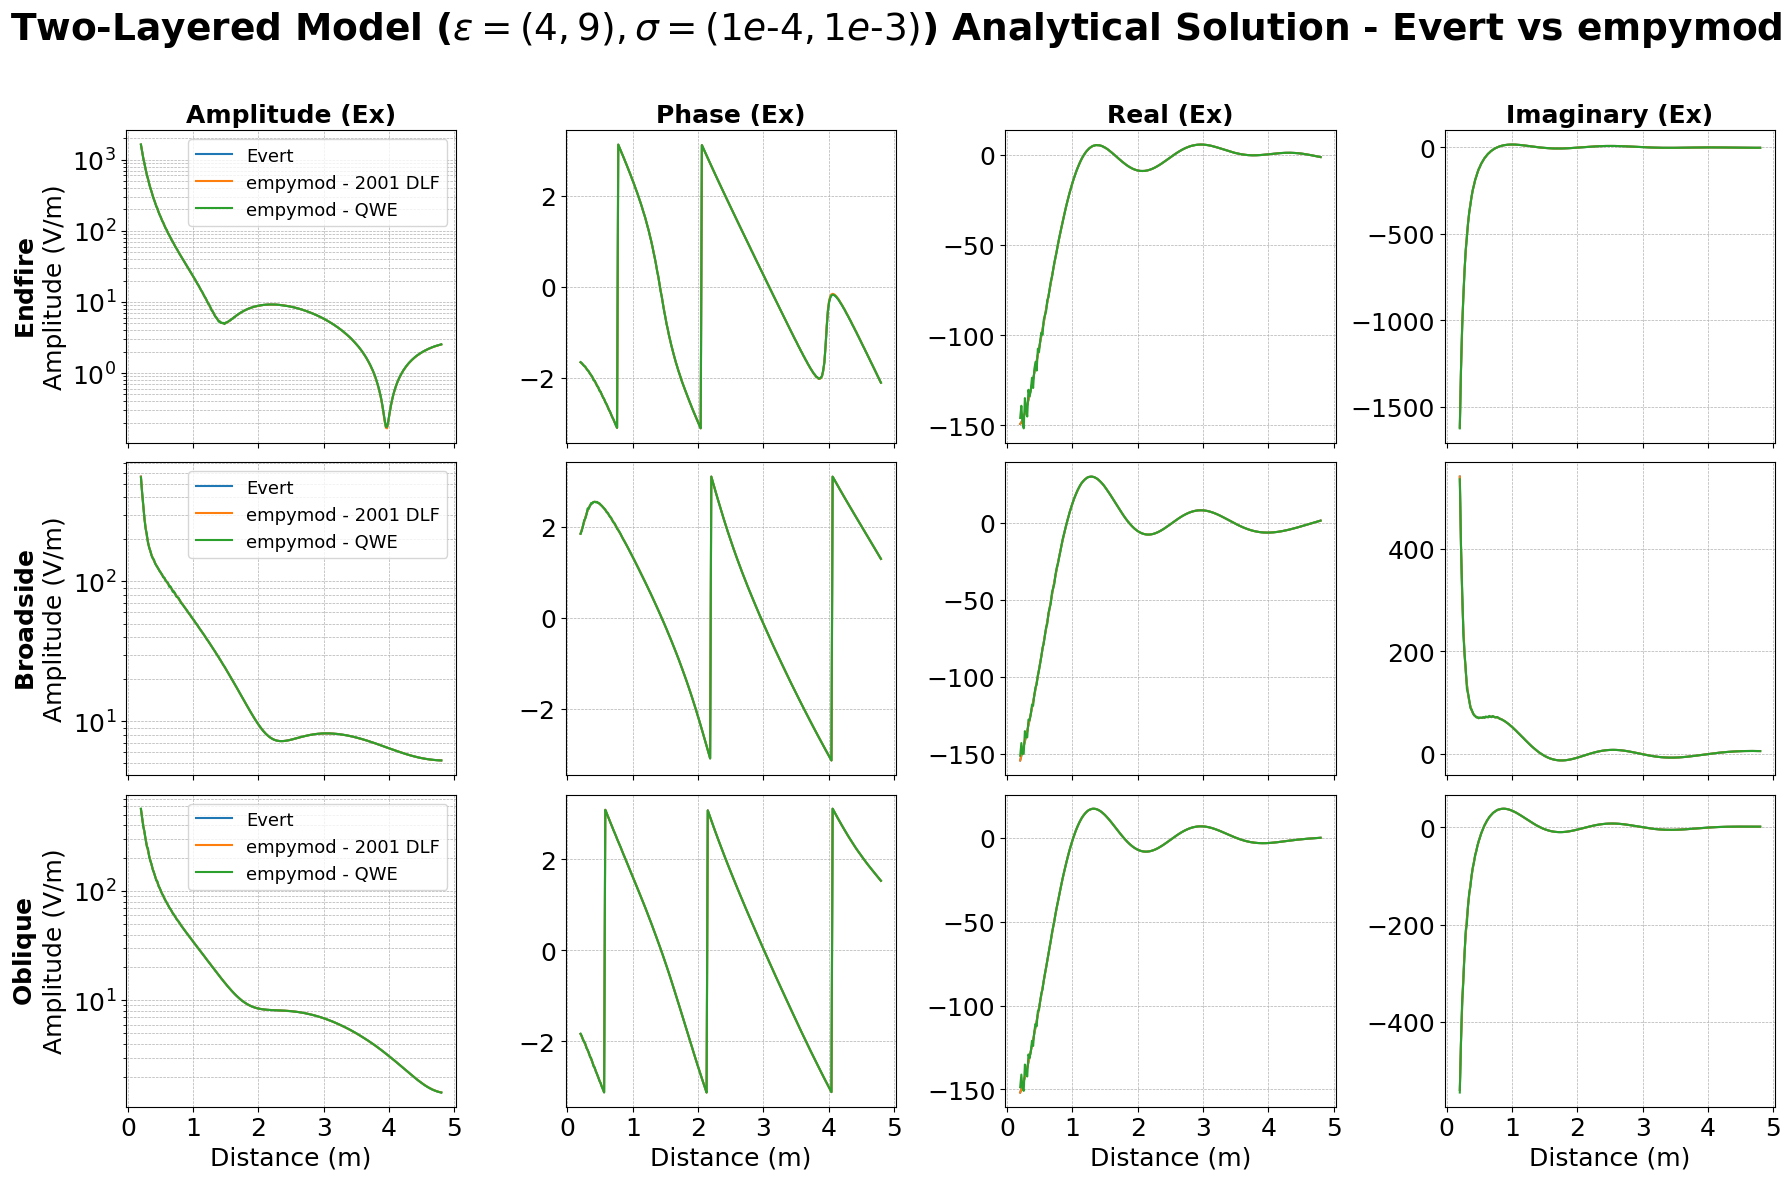

In [10]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12), sharex=True)

# Use datasets from both Evert and empymod
datasets_4_9 = dataset_evert_4_9 + dataset_empymod_4_9_dlf + dataset_empymod_4_9_qwe

font_suptitle = 27
font_label = 18
font_tick = 18
font_legend = 13

for i, (amp, phase, real, imag, label, axis, source) in enumerate(datasets_4_9):
    row = i % 3
    for col, (title, ylabel) in enumerate(quantities):
        ax = axes[row, col]
        plot_label = source
        if col == 0:
            ax.semilogy(axis, [amp, phase, real, imag][col], label=plot_label)
            ax.grid(True, which='both', linestyle='--', linewidth=0.5)
            ax.legend(fontsize=font_legend, loc='upper right')
        else:
            ax.plot(axis, [amp, phase, real, imag][col], label=plot_label)
            ax.grid(True, linestyle='--', linewidth=0.5)
        if row == 0:
            ax.set_title(title, fontsize=font_label, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f"$\\bf{{{label}}}$\n{ylabel}", fontsize=font_label)
        if row == 2:
            ax.set_xlabel('Distance (m)', fontsize=font_label)
        xticks = np.arange(np.floor(axis.min() * 2) / 2, np.ceil(axis.max() * 2) / 2 + 0.01, 1)
        ax.set_xticks(xticks)
        ax.tick_params(axis='both', which='major', labelsize=font_tick)
    
fig.suptitle(r"Two-Layered Model ($\varepsilon=(4,9), \sigma=(1e\text{-}4,1e\text{-}3)$) Analytical Solution - Evert vs empymod", fontsize=font_suptitle, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(base_folder, "two_layered_model_4_9_solution_comparison.png"), dpi=300)
plt.show()

### Error Plot

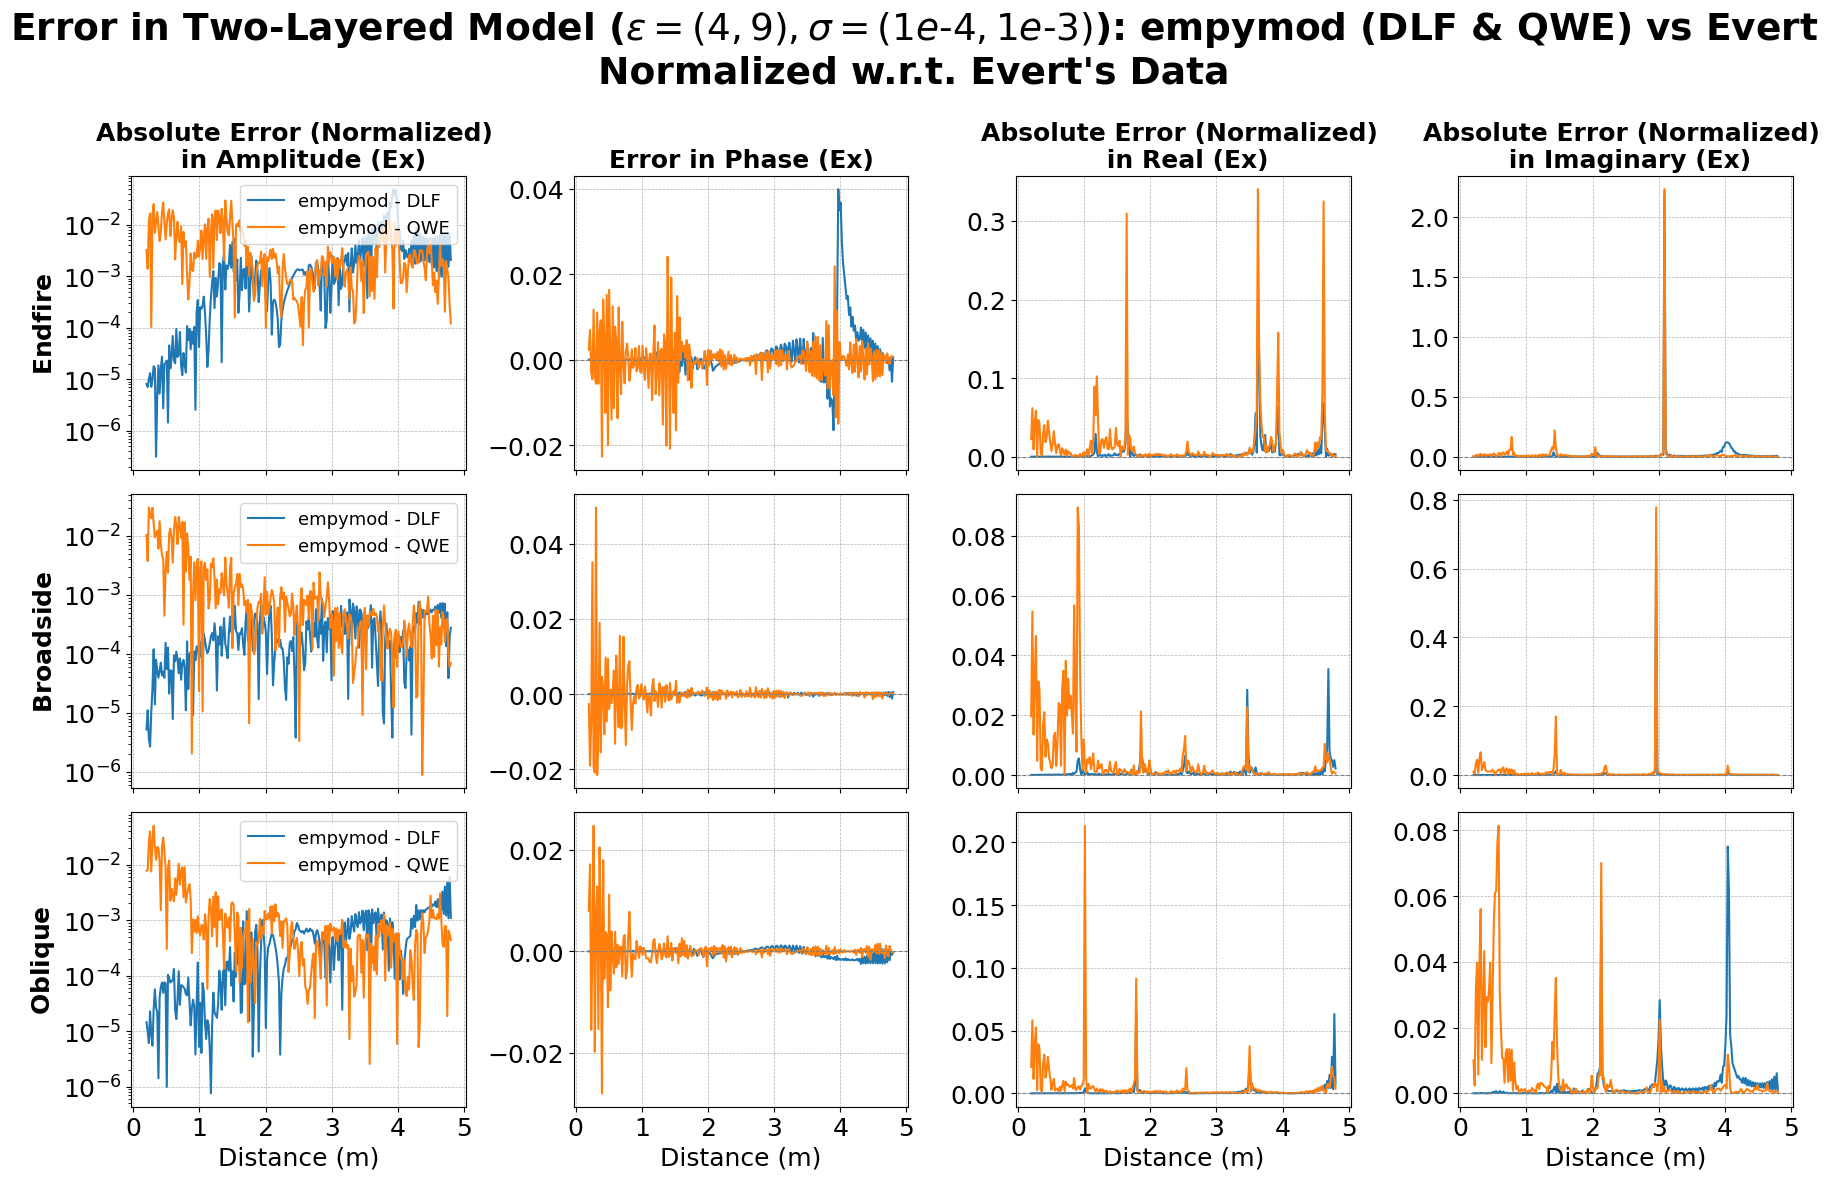

In [11]:
# Calculate normalised differences between Evert and both empymod datasets for each orientation and quantity
diff_datasets_4_9 = []
for i in range(3):  # Endfire, Broadside, Oblique
    evert = dataset_evert_4_9[i]
    empy_dlf = dataset_empymod_4_9_dlf[i]
    empy_qwe = dataset_empymod_4_9_qwe[i]
    amp_diff_dlf = np.abs(empy_dlf[0] - evert[0]) / np.abs(evert[0])
    phase_diff_dlf = empy_dlf[1] - evert[1]
    real_diff_dlf = np.abs(empy_dlf[2] - evert[2]) / np.abs(evert[2])
    imag_diff_dlf = np.abs(empy_dlf[3] - evert[3]) / np.abs(evert[3])
    amp_diff_qwe = np.abs(empy_qwe[0] - evert[0]) / np.abs(evert[0])
    phase_diff_qwe = empy_qwe[1] - evert[1]
    real_diff_qwe = np.abs(empy_qwe[2] - evert[2]) / np.abs(evert[2])
    imag_diff_qwe = np.abs(empy_qwe[3] - evert[3]) / np.abs(evert[3])
    diff = (
        (amp_diff_dlf, phase_diff_dlf, real_diff_dlf, imag_diff_dlf),
        (amp_diff_qwe, phase_diff_qwe, real_diff_qwe, imag_diff_qwe),
        evert[4],  # Label
        evert[5]   # r
    )
    diff_datasets_4_9.append(diff)

fig, axes = plt.subplots(3, 4, figsize=(18, 12), sharex=True)
for row, (diff_dlf, diff_qwe, label, axis) in enumerate(diff_datasets_4_9):
    for col, (title, ylabel) in enumerate(quantities):
        ax = axes[row, col]
        if col == 0:
            ax.semilogy(axis, diff_dlf[col], label='empymod - DLF')
            ax.semilogy(axis, diff_qwe[col], label='empymod - QWE')
        else:
            ax.plot(axis, diff_dlf[col], label='empymod - DLF')
            ax.plot(axis, diff_qwe[col], label='empymod - QWE')
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
        ax.grid(True, linestyle='--', linewidth=0.5)
        if row == 0:
            if title != 'Phase (Ex)':
                ax.set_title(f"Absolute Error (Normalized) \n in {title}", fontsize=font_label, fontweight='bold')
            else:
                ax.set_title(f"Error in {title}", fontsize=font_label, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f"$\\bf{{{label}}}$", fontsize=font_label)
        if row == 2:
            ax.set_xlabel('Distance (m)', fontsize=font_label)
        xticks = np.arange(np.floor(axis.min() * 2) / 2, np.ceil(axis.max() * 2) / 2 + 0.01, 1)
        ax.set_xticks(xticks)
        ax.tick_params(axis='both', which='major', labelsize=font_tick)
        if col == 0:
            ax.legend(fontsize=font_legend, loc='upper right')

fig.suptitle(r"Error in Two-Layered Model ($\varepsilon=(4,9), \sigma=(1e\text{-}4,1e\text{-}3)$): empymod (DLF & QWE) vs Evert" "\n" r"Normalized w.r.t. Evert's Data", fontsize=font_suptitle, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(os.path.join(base_folder, "two_layered_model_4_9_solution_normalized_error.png"), dpi=300)
plt.show()
